In [1]:
# =============================================================
# 실습 2 · 임베딩 학습 전/후 시각화
# Google Colab Version
# =============================================================
# 목표: Embedding + Dense 분류 모델을 학습하고,
#       학습 전(랜덤)/후 임베딩을 t-SNE로 비교한다.
# =============================================================

# -------------------------------------------------------------
# 0. 패키지 설치 — Colab 최초 실행 시 이 셀만 먼저 실행
# -------------------------------------------------------------
!pip install -q koreanize-matplotlib

# -------------------------------------------------------------
# 1. Setup
# -------------------------------------------------------------
import io
import requests
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import koreanize_matplotlib

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 58.0 MB/s eta 0:00:00


In [2]:

# =============================================================
# Part A · 데이터 로드 + 분할
# =============================================================

# Fix 1: URL에서 직접 npz 로드 (로컬 파일 불필요)
url = "https://raw.githubusercontent.com/hongsukyi/Lectures/main/data/aihub_3class_n2400.npz"

print("데이터 다운로드 중...")
response = requests.get(url)
response.raise_for_status()
data = np.load(io.BytesIO(response.content), allow_pickle=True)
print("다운로드 완료")
print("-" * 60)

X = data["input_ids"]
y = data["labels"]

VOCAB_SIZE  = int(data["vocab_size"])
MAX_LEN     = int(data["max_len"])
PAD_ID      = int(data["pad_id"])
NUM_CLASSES = int(data["num_classes"])
class_names = data["class_names"].tolist()

print(f"VOCAB: {VOCAB_SIZE:,}, MAX_LEN: {MAX_LEN}, PAD_ID: {PAD_ID}")
print(f"Classes: {class_names}")
print("-" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("-" * 60)


데이터 다운로드 중...
다운로드 완료
------------------------------------------------------------
VOCAB: 32,000, MAX_LEN: 32, PAD_ID: 0
Classes: ['면접', '학교', '협상']
------------------------------------------------------------
Train: (1920, 32), Test: (480, 32)
------------------------------------------------------------


In [3]:
# =============================================================
# Part B · 모델 구성: Embedding + Conv1D + GlobalMaxPooling + Dense
# =============================================================

EMBEDDING_DIM = 64
NUM_FILTERS   = 128
KERNEL_SIZE   = 5

def build_conv1d():
    model = keras.Sequential([
        layers.Input(shape=(MAX_LEN,)),
        layers.Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            mask_zero=False,          # Conv1D는 마스킹 미지원 → 반드시 False
            name="embedding"
        ),
        layers.Conv1D(
            filters=NUM_FILTERS,
            kernel_size=KERNEL_SIZE,
            activation="relu",
            padding="same",
            name="conv1d"
        ),
        layers.GlobalMaxPooling1D(name="sentence_vector"),   # n-gram 특징의 최댓값 = 문장 벡터
        layers.Dense(64, activation="relu",             name="hidden"),
        layers.Dense(NUM_CLASSES, activation="softmax",  name="output"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_conv1d()
model.summary()
print("-" * 60)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 32, 64)         │     2,048,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 32, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentence_vector                 │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,097,539 (8.00 MB)

 Trainable params: 2,097,539 (8.00 MB)

 Non-trainable params: 0 (0.00 B)

------------------------------------------------------------


In [4]:

# =============================================================
# Part C · 문장 임베딩 추출 함수 + t-SNE 시각화 함수
# =============================================================

def extract_sentence_vectors(model, X_data):
    """embedding → conv1d → sentence_vector 까지 실행하여 문장 벡터 추출"""
    emb_layer  = model.get_layer("embedding")
    conv_layer = model.get_layer("conv1d")
    pool_layer = model.get_layer("sentence_vector")
    inp = layers.Input(shape=(MAX_LEN,))
    x   = emb_layer(inp)
    x   = conv_layer(x)          # ← Conv1D 단계 추가
    x   = pool_layer(x)
    extractor = keras.Model(inputs=inp, outputs=x)
    return extractor.predict(X_data, batch_size=256, verbose=0)


def plot_tsne(vectors, labels, class_names, title, save_path=None):
    """t-SNE 2D 시각화"""
    tsne = TSNE(
        n_components=2,
        perplexity=40,
        max_iter=1000,
        learning_rate="auto",
        init="pca",
        random_state=SEED
    )
    emb_2d = tsne.fit_transform(vectors)
    colors = ["#E02020", "#1A8F3C", "#1A40E0"]

    plt.figure(figsize=(8, 6))
    for i, name in enumerate(class_names):
        mask = (labels == i)
        plt.scatter(
            emb_2d[mask, 0], emb_2d[mask, 1],
            c=colors[i], label=name,
            alpha=0.5, s=15, edgecolors="none"
        )
    plt.title(title, fontsize=14, fontweight="bold")
    plt.legend(fontsize=11, markerscale=2)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"[저장] {save_path}")
    plt.show()



[학습 전] 랜덤 초기화 상태의 문장 임베딩 추출...
[저장] fig02_embedding_before.png


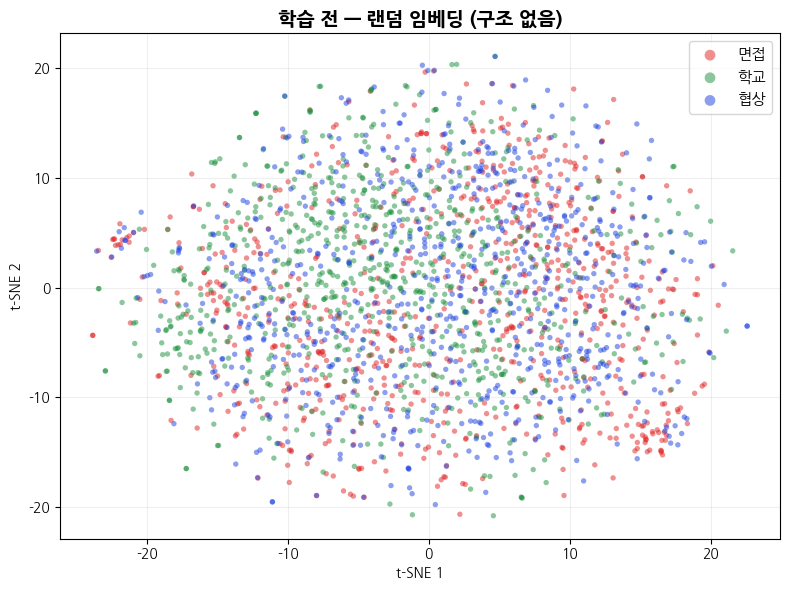

In [5]:

# =============================================================
# Part D · 시각화 1 — 학습 전 (랜덤 초기화)
# =============================================================

print("[학습 전] 랜덤 초기화 상태의 문장 임베딩 추출...")
vectors_before = extract_sentence_vectors(model, X)

plot_tsne(
    vectors_before, y, class_names,
    title="학습 전 — 랜덤 임베딩 (구조 없음)",
    save_path="fig02_embedding_before.png"
)


In [9]:


# =============================================================
# Part E · 모델 학습
# =============================================================

EPOCHS     = 20
BATCH_SIZE = 128

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=10, verbose=1
        ),
    ],
    verbose=1
)

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n[결과] 테스트 정확도: {acc:.4f}")
print("-" * 60)


Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9865 - loss: 0.0914 - val_accuracy: 0.8521 - val_loss: 0.3854 - learning_rate: 5.0000e-04
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9937 - loss: 0.0644 - val_accuracy: 0.8562 - val_loss: 0.3777 - learning_rate: 5.0000e-04
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9974 - loss: 0.0435 - val_accuracy: 0.8583 - val_loss: 0.3775 - learning_rate: 5.0000e-04
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9990 - loss: 0.0302 - val_accuracy: 0.8604 - val_loss: 0.3800 - learning_rate: 5.0000e-04
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 1.0000 - loss: 0.0217 - val_accuracy: 0.8604 - val_loss: 0.3837 - learning_rate: 5.0000e-04
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 1.0000 - loss: 0.0162 - val_accuracy: 0.8604 - val_loss: 0.3881 - learning_rate: 5.0000e-04
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 1.0000 

[학습 후] 학습된 임베딩의 문장 벡터 추출...
[저장] fig02_embedding_after.png


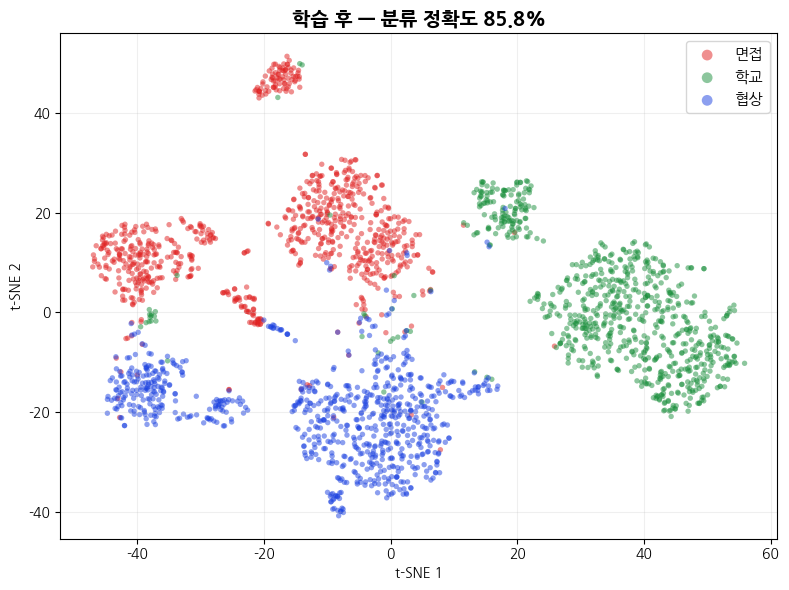

In [10]:


# =============================================================
# Part F · 시각화 2 — 학습 후
# =============================================================

print("[학습 후] 학습된 임베딩의 문장 벡터 추출...")
vectors_after = extract_sentence_vectors(model, X)

plot_tsne(
    vectors_after, y, class_names,
    title=f"학습 후 — 분류 정확도 {acc:.1%}",
    save_path="fig02_embedding_after.png"
)


[저장] fig02_training_curve_dense.png


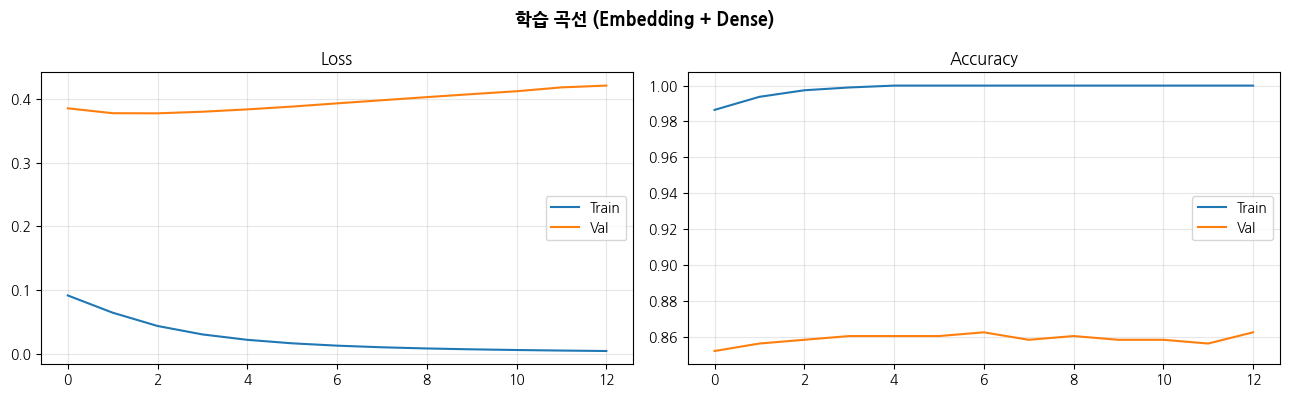

In [11]:


# =============================================================
# Part G · 학습 곡선
# =============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history.history["loss"],     label="Train")
ax1.plot(history.history["val_loss"], label="Val")
ax1.set_title("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history["accuracy"],     label="Train")
ax2.plot(history.history["val_accuracy"], label="Val")
ax2.set_title("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("학습 곡선 (Embedding + Dense)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig02_training_curve_dense.png", dpi=150, bbox_inches="tight")
print("[저장] fig02_training_curve_dense.png")
plt.show()
